# Diagnóstico de Câncer de Mama com Machine Learning

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O câncer de mama é o tipo de câncer mais comum entre mulheres no mundo. A detecção precoce é fundamental para aumentar as chances de tratamento bem-sucedido. Neste notebook, vamos construir modelos de Machine Learning capazes de classificar tumores de mama como **malignos** ou **benignos** com base em características extraídas de imagens digitalizadas de aspiração por agulha fina (FNA) de massas mamárias.

### Dataset

Utilizaremos o **Wisconsin Breast Cancer Dataset**, disponível diretamente pelo scikit-learn. O dataset contém 569 amostras com 30 features numéricas extraídas de imagens de células, como raio médio, textura, perímetro, área, suavidade, entre outras.

### Objetivo

Treinar e comparar diferentes modelos de classificação para identificar qual apresenta o melhor desempenho no diagnóstico de câncer de mama, sempre lembrando que **o médico deve ter a palavra final** no diagnóstico.

---

## 1. Importação das Bibliotecas

Vamos começar importando as bibliotecas que serão utilizadas ao longo do notebook. Escolhemos ferramentas padrão do ecossistema Python para ciência de dados e ML.

In [6]:
# Bibliotecas para manipulação de dados
%pip install -r ../requirements.txt
import pandas as pd
import numpy as np
import os

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# SHAP para interpretabilidade
import shap

# Importar nossas funções auxiliares
import sys
sys.path.append('..')
from src.utils import (
    plotar_distribuicao_classes, plotar_histogramas, plotar_correlacao,
    plotar_matriz_confusao, plotar_curvas_roc_comparativas,
    avaliar_modelo, comparar_modelos, exibir_classification_report
)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Ignorar avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-n

In [7]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f"Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}")

Gráficos serão salvos em: c:\Users\rrvr\vsCode_Workspace\tech-challenge-1\resultados


## 2. Carregamento e Exploração dos Dados (EDA)

Vamos carregar o dataset e entender sua estrutura. É importante conhecer bem os dados antes de qualquer modelagem — isso nos ajuda a tomar decisões melhores nas etapas seguintes.

### 2.1 Carregamento do Dataset

In [8]:
# Carregar o dataset de câncer de mama a partir do CSV
# O CSV foi gerado pelo script data/download_datasets.py
# Fonte original: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

caminho_csv = os.path.join('..', 'data', 'cancer_mama.csv')

# Se o CSV ainda não existe, rodar o script de download
if not os.path.exists(caminho_csv):
    print("CSV não encontrado. Executando script de download...")
    sys.path.append(os.path.join('..', 'data'))
    from download_datasets import baixar_cancer_mama
    baixar_cancer_mama()

# Carregar o CSV
df = pd.read_csv(caminho_csv)

# Separar nomes das features (todas as colunas exceto 'diagnostico')
feature_names = [col for col in df.columns if col != 'diagnostico']

print(f"Dataset carregado de: {caminho_csv}")
print(f"Formato do dataset: {df.shape[0]} amostras e {df.shape[1]} colunas")
print(f"\nFeatures disponíveis: {feature_names}")
print(f"\nClasses: 0 = Maligno, 1 = Benigno")
df.head()

CSV não encontrado. Executando script de download...
Baixando dataset de Cancer de Mama Wisconsin (Kaggle)...
Dataset salvo em: C:\Users\rrvr\vsCode_Workspace\tech-challenge-1\data\cancer_mama.csv
Formato: 569 amostras, 32 colunas
Dataset carregado de: ..\data\cancer_mama.csv
Formato do dataset: 569 amostras e 32 colunas

Features disponíveis: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Classes: 0 = Maligno, 1 = Benigno


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.2 Informações Gerais do Dataset

Vamos verificar os tipos de dados, se há valores nulos e as estatísticas descritivas básicas.

In [9]:
# Informações gerais do DataFrame
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

In [10]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum().to_string())
print(f"\nTotal de valores nulos no dataset: {df.isnull().sum().sum()}")

Valores nulos por coluna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0

Total de valores nulos no dataset: 0


In [11]:
# Estatísticas descritivas
# Isso nos ajuda a entender a escala, a dispersão e a distribuição de cada feature
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Foi verificado que a coluna 'diagnosis' esta como object, vamos converter para numérica (0 e 1) para facilitar a modelagem.
Converter a coluna 'diagnosis' para numérica (0 = maligno, 1 = benigno)

In [12]:
df['diagnostico'] = df['diagnosis'].map({'M': 0, 'B': 1})
df.drop('diagnosis', axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### 2.3 Distribuição das Classes

Uma etapa importante é verificar se as classes estão balanceadas. Se houver um desbalanceamento muito grande, os modelos podem ficar enviesados para a classe majoritária, o que seria perigoso em um contexto médico — imagine um modelo que "acerta muito" mas na verdade só classifica tudo como benigno.

  → Gráfico salvo em: ..\resultados\cm_distribuicao_classes.png


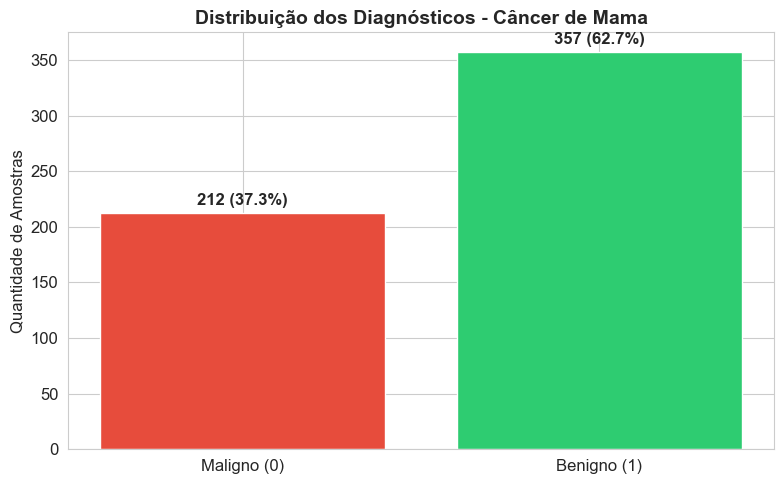

Proporção das classes:
  Maligno:  212 (37.3%)
  Benigno:  357 (62.7%)


In [14]:
# Distribuição das classes
# No dataset: 0 = maligno, 1 = benigno
plotar_distribuicao_classes(
    df['diagnostico'],
    nomes_classes=['Maligno (0)', 'Benigno (1)'],
    titulo='Distribuição dos Diagnósticos - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_distribuicao_classes.png')
)

# Proporção exata
print(f"Proporção das classes:")
print(f"  Maligno:  {(df['diagnostico'] == 0).sum()} ({(df['diagnostico'] == 0).mean()*100:.1f}%)")
print(f"  Benigno:  {(df['diagnostico'] == 1).sum()} ({(df['diagnostico'] == 1).mean()*100:.1f}%)")

### Análise do balanceamento das classes

O dataset apresenta uma distribuição de classes levemente desbalanceada, com aproximadamente **63% de instâncias benignas** e **37% de instâncias malignas**. Embora exista uma diferença entre as classes, esse nível de desbalanceamento não é considerado crítico.

Em termos práticos, a classe minoritária (maligna) ainda possui representatividade suficiente para que os modelos de aprendizado de máquina consigam identificar padrões relevantes sem necessidade de técnicas adicionais de balanceamento.


### Justificativa para não utilização de técnicas de balanceamento

Técnicas como o **SMOTE (Synthetic Minority Over-sampling Technique)** são geralmente recomendadas em cenários onde há desbalanceamento severo, por exemplo, quando a classe minoritária representa menos de 20% do conjunto de dados.

No presente caso, a proporção de 37% para a classe minoritária indica que:

- Há quantidade suficiente de amostras para aprendizado adequado;
- O risco de viés extremo para a classe majoritária é reduzido;
- A aplicação de técnicas de oversampling poderia introduzir **ruído artificial** e potencialmente levar ao **overfitting**, prejudicando a capacidade de generalização do modelo.

Dessa forma, optou-se por **não aplicar técnicas de balanceamento** neste momento.


### 2.4 Distribuição das Features

Nesta etapa, analisamos a distribuição das *features* (variáveis explicativas) com o objetivo de compreender melhor o comportamento dos dados e identificar possíveis padrões ou a presença de outliers.

As *features* representam as características observadas em cada registro do dataset e são utilizadas como base para a predição da variável alvo (*target*), que corresponde à informação que o modelo busca prever.

A análise da distribuição dessas variáveis permite:

- Identificar a presença de valores extremos (*outliers*), que são observações significativamente distantes do padrão geral dos dados;
- Verificar assimetrias, dispersões e possíveis inconsistências;
- Compreender melhor a relação entre as variáveis e seu impacto na predição.

Os *outliers* podem representar tanto ruídos quanto comportamentos reais do dataset, sendo importante avaliá-los com cautela antes de decidir por sua remoção ou tratamento.

Vamos fazer uma tratativa , alterando os nomes dos cabeçalhos para facilitar a visualização e interpretação dos gráficos. Por exemplo, vamos substituir "mean radius" por "Raio Médio", "mean texture" por "Textura Média", e assim por diante. Essa abordagem torna os gráficos mais acessíveis, especialmente para aqueles que não estão familiarizados com os termos técnicos em inglês.

Atenção: colunas sem tradução: {'diagnostico'}
Features de valores médios: ['raio_media', 'textura_media', 'perimetro_media', 'area_media', 'suavidade_media', 'compacidade_media', 'concavidade_media', 'pontos_concavos_media', 'simetria_media', 'dimensao_fractal_media']


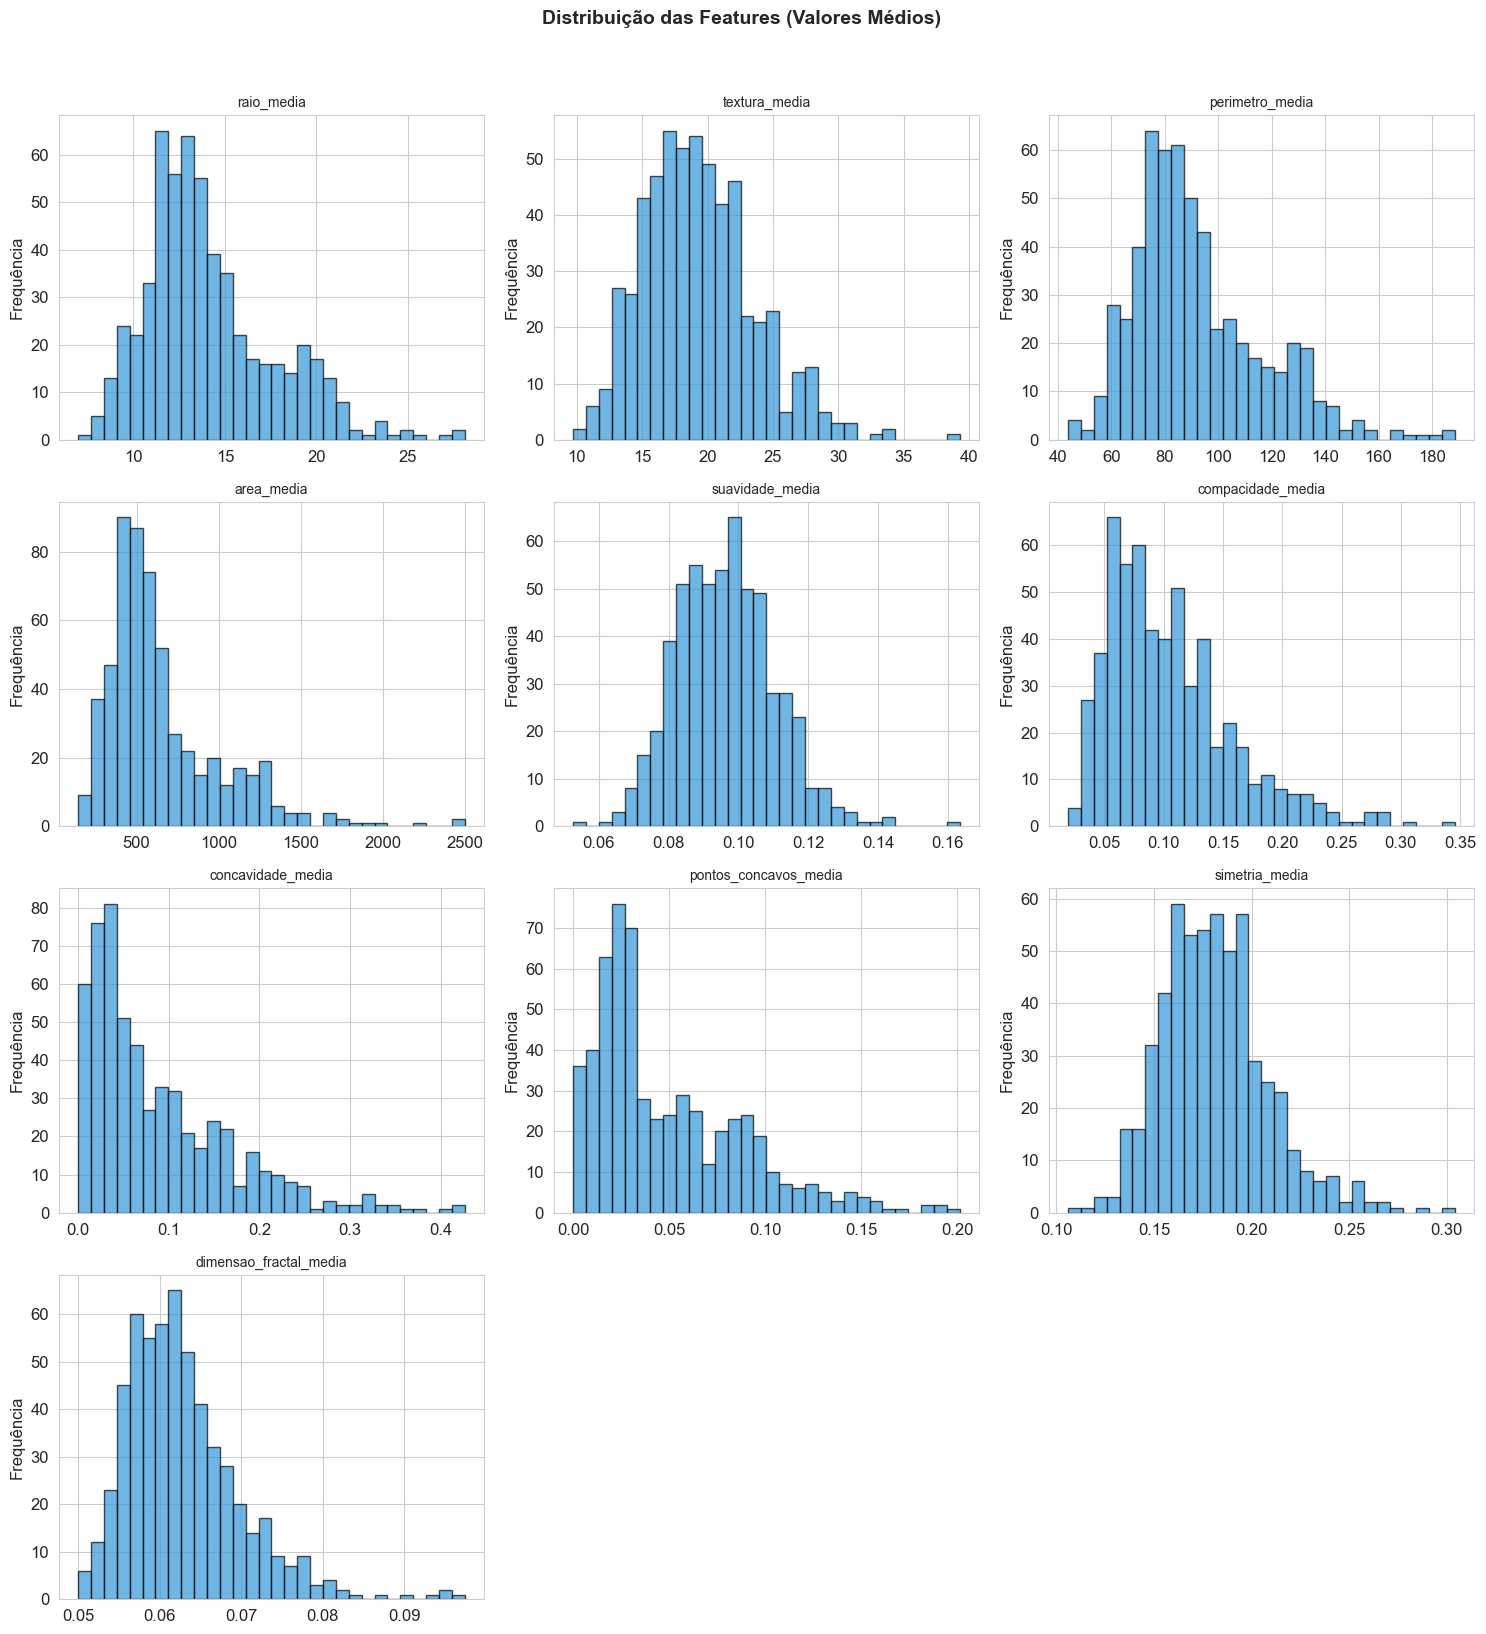

In [15]:
# Mapeamento direto: nome original -> nome traduzido
traducao_colunas = {
    'id': 'id',
    'diagnosis': 'diagnostico',

    # Valores médios (mean)
    'radius_mean': 'raio_media',
    'texture_mean': 'textura_media',
    'perimeter_mean': 'perimetro_media',
    'area_mean': 'area_media',
    'smoothness_mean': 'suavidade_media',
    'compactness_mean': 'compacidade_media',
    'concavity_mean': 'concavidade_media',
    'concave points_mean': 'pontos_concavos_media',
    'symmetry_mean': 'simetria_media',
    'fractal_dimension_mean': 'dimensao_fractal_media',

    # Erro padrão (se)
    'radius_se': 'raio_ep',
    'texture_se': 'textura_ep',
    'perimeter_se': 'perimetro_ep',
    'area_se': 'area_ep',
    'smoothness_se': 'suavidade_ep',
    'compactness_se': 'compacidade_ep',
    'concavity_se': 'concavidade_ep',
    'concave points_se': 'pontos_concavos_ep',
    'symmetry_se': 'simetria_ep',
    'fractal_dimension_se': 'dimensao_fractal_ep',

    # Pior valor (worst)
    'radius_worst': 'raio_pior',
    'texture_worst': 'textura_pior',
    'perimeter_worst': 'perimetro_pior',
    'area_worst': 'area_pior',
    'smoothness_worst': 'suavidade_pior',
    'compactness_worst': 'compacidade_pior',
    'concavity_worst': 'concavidade_pior',
    'concave points_worst': 'pontos_concavos_pior',
    'symmetry_worst': 'simetria_pior',
    'fractal_dimension_worst': 'dimensao_fractal_pior',
}

def traduzir_colunas(df, mapeamento=traducao_colunas):
    """
    Lê as colunas do DataFrame e traduz os cabeçalhos para português.
    Retorna um novo DataFrame com as colunas renomeadas.
    """
    # Verifica quais colunas do df estão no mapeamento (evita erros)
    colunas_para_traduzir = {k: v for k, v in mapeamento.items() if k in df.columns}

    # Avisa sobre colunas não mapeadas
    nao_mapeadas = set(df.columns) - set(colunas_para_traduzir.keys())
    if nao_mapeadas:
        print(f"Atenção: colunas sem tradução: {nao_mapeadas}")

    return df.rename(columns=colunas_para_traduzir)


# Aplica a tradução
df = traduzir_colunas(df)
feature_names = df.columns.tolist()

# Agora filtra as features de valores médios
features_mean = [col for col in feature_names if col.endswith('_media')]
print(f"Features de valores médios: {features_mean}")

plotar_histogramas(df, features_mean, titulo='Distribuição das Features (Valores Médios)')

### Análise dos histogramas

A partir da análise dos histogramas, observa-se que algumas features, como `raio_media`, `perimetro_media` e `area_media`, apresentam distribuições assimétricas à direita (right-skewed), com maior concentração de valores mais baixos e uma cauda estendida para valores mais altos. Esse comportamento sugere a presença de observações com valores elevados, que podem ser interpretadas como possíveis outliers ou variações relevantes nas dimensões dos tumores.

Por outro lado, variáveis como `suavidade_media` e `simetria_media` apresentam distribuições mais próximas da simetria, indicando uma dispersão mais homogênea e menor influência de valores extremos.

Entretanto, é importante destacar que essa análise é univariada e, portanto, não permite inferir diretamente a capacidade discriminativa das features em relação à variável alvo (benigno vs maligno). Para uma avaliação mais robusta, seria necessário analisar a distribuição dessas variáveis considerando a separação por classe, por meio de técnicas como boxplots condicionados ao target ou outras abordagens estatísticas.


### Questionamentos levantados

- As distribuições assimétricas observadas podem impactar o desempenho dos modelos de machine learning?
- Os valores extremos identificados representam ruído ou características relevantes do problema?
- Quais features tem mais capacidade de discriminar entre tumores benignos e malignos?
- As variáveis seguem uma distribuição normal e isso é relevante para os modelos escolhidos?
- Existe correlação ou redundância entre variáveis como `raio_media`, `perimetro_media` e `area_media`?

### Discussão inicial

As distribuições assimétricas podem influenciar o desempenho de alguns algoritmos, especialmente aqueles sensíveis à escala e à distribuição dos dados. Nesse sentido, transformações como normalização ou padronização podem ser consideradas.

Em relação aos valores extremos, é importante destacar que, em datasets da área da saúde, esses valores podem representar casos reais e relevantes, como tumores com dimensões maiores. Portanto, a remoção de outliers deve ser realizada com cautela, após análise mais aprofundada.

Além disso, a análise univariada realizada até o momento não permite avaliar diretamente o poder discriminativo das variáveis. Para isso, será necessário considerar a relação das features com a variável alvo, por meio de análises adicionais, como visualizações por classe e métricas estatísticas.

Para simplificar a análise e reduzir a complexidade dos dados, consideraremos apenas as features médias. Essa abordagem melhora a interpretabilidade dos dados, reduz a dimensionalidade e facilita etapas posteriores, como o treinamento dos modelos.

Por fim, considerando a possível relação entre algumas variáveis (como raio, perímetro e área), torna-se relevante investigar a existência de correlação entre elas, uma vez que isso pode impactar modelos sensíveis à multicolinearidade.

### Próximos passos

Com base nos questionamentos levantados, as próximas etapas da análise incluirão:

- Avaliação da distribuição das variáveis por classe (benigno vs maligno);
- Análise de correlação entre as features;
- Identificação do impacto de outliers no desempenho dos modelos;
- Aplicação de técnicas de pré-processamento, quando necessário;
- Avaliação do poder discriminativo das variáveis.

Essas etapas são fundamentais para garantir uma modelagem mais robusta e bem fundamentada.

Boxplots para comparação entre classes (maligno vs. benigno)

Para analisar as diferenças entre tumores malignos e benignos, utilizamos boxplots de algumas features consideradas relevantes. Essas variáveis foram escolhidas por representarem aspectos importantes como tamanho, forma e textura dos tumores.

1. Representatividade geométrica do tumor
raio_media, perimetro_media, area_media
Essas variáveis estão diretamente relacionadas ao tamanho e à escala do tumor. Em geral, tumores malignos tendem a apresentar maiores dimensões ou crescimento mais irregular, tornando essas features altamente informativas para a diferenciação entre classes.

2. Textura e heterogeneidade
textura_media
Essa feature captura variações na intensidade dos pixels nas imagens médicas, refletindo a heterogeneidade do tecido. Tumores malignos costumam apresentar texturas mais irregulares.

3. Regularidade da borda
suavidade_media
Indica o grau de suavidade ou irregularidade do contorno do tumor. Tumores malignos geralmente possuem bordas menos regulares.

4. Formato e compactação
compacidade_media
Relaciona área e perímetro para medir o quão compacto é o tumor. Tumores benignos tendem a apresentar formas mais regulares e compactas, enquanto tumores malignos costumam ser mais irregulares e dispersos.

  → Gráfico salvo em: ..\resultados\cm_boxplots.png


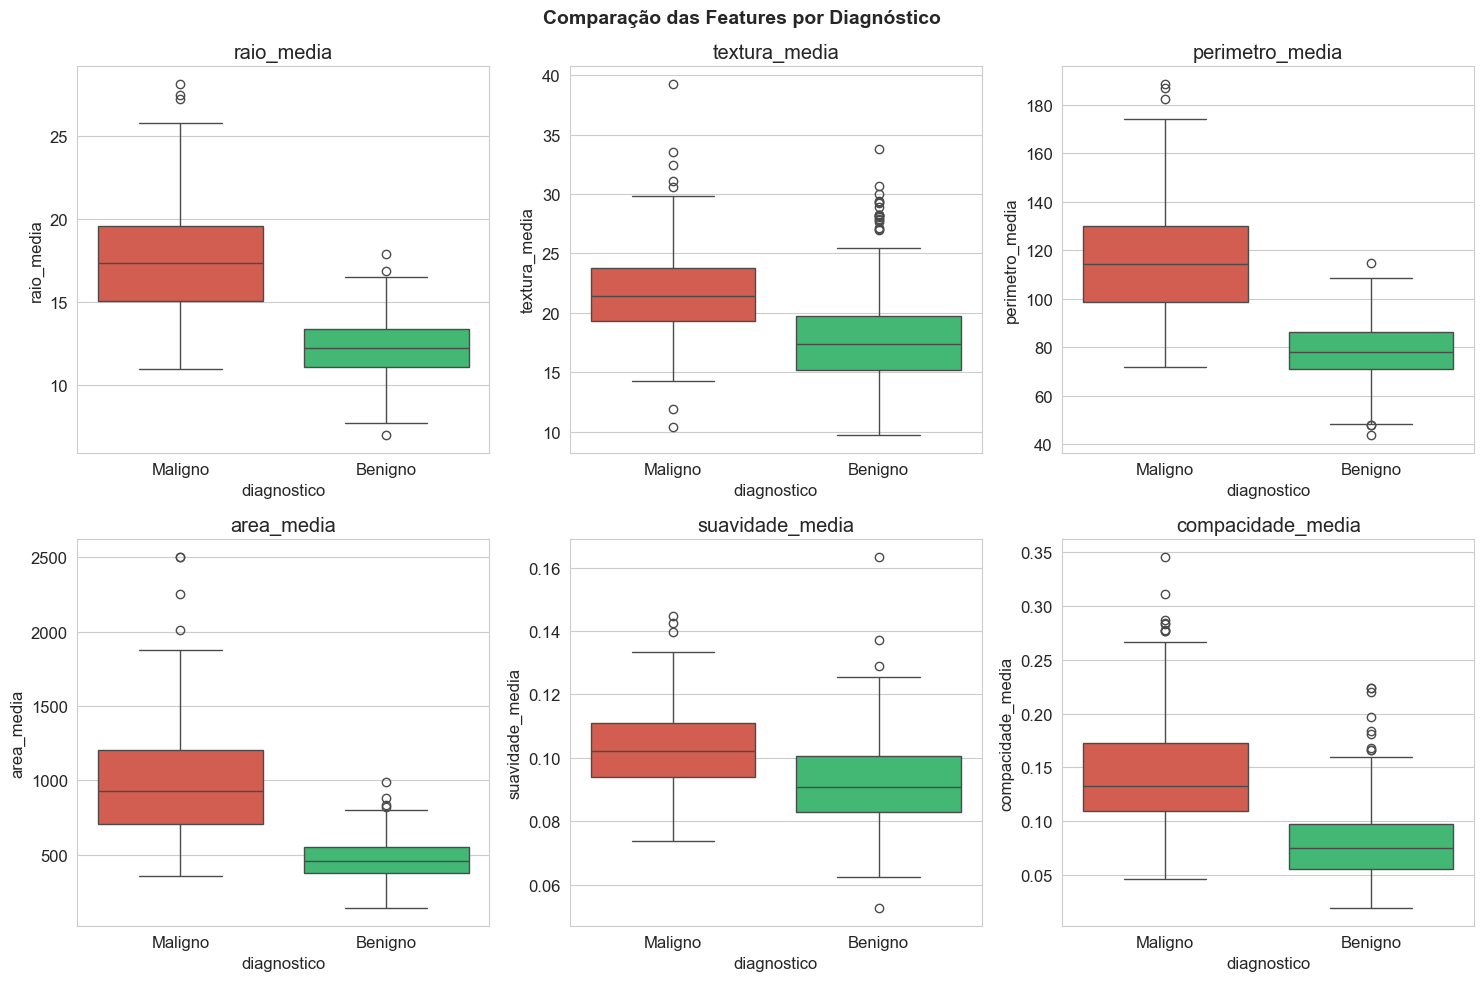

In [20]:
features_destaque = ['raio_media', 'textura_media', 'perimetro_media', 'area_media',
                     'suavidade_media', 'compacidade_media']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_destaque):
    sns.boxplot(data=df, x='diagnostico', y=feature, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_xticklabels(['Maligno', 'Benigno'])
    axes[i].set_title(feature)

fig.suptitle('Comparação das Features por Diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_boxplots.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_boxplots.png')}")
plt.show()

Análise dos boxplots

Observa-se que features como raio_medio, perimetro_medio e area_media apresentam uma separação bastante clara entre tumores malignos e benignos. Em geral, tumores malignos tendem a possuir valores mais elevados nessas medidas, o que é consistente do ponto de vista biológico, já que costumam crescer mais e de forma menos controlada.

Por outro lado, a feature suavidade_media apresenta menor capacidade de separação entre as classes, indicando que pode ter um poder discriminativo mais limitado para a tarefa de classificação.

3. Pré-processamento dos Dados

Antes do treinamento dos modelos, é fundamental preparar os dados adequadamente. Essa etapa garante melhor desempenho e maior confiabilidade nos resultados. O pré-processamento inclui:

Separação entre variáveis preditoras (features) e variável alvo
Análise de correlação entre as features
Aplicação de escalonamento (feature scaling)
Divisão dos dados em conjuntos de treino e teste
3.1 Análise de Correlação

Nesta etapa, analisamos a correlação entre as features para identificar possíveis relações fortes entre elas. Variáveis altamente correlacionadas podem introduzir redundância no modelo, especialmente em algoritmos mais sensíveis a esse aspecto.

Ainda assim, neste primeiro momento, optamos por manter todas as features e observar como os modelos se comportam antes de aplicar qualquer técnica de redução de dimensionalidade.

  → Gráfico salvo em: ..\resultados\cm_correlacao.png


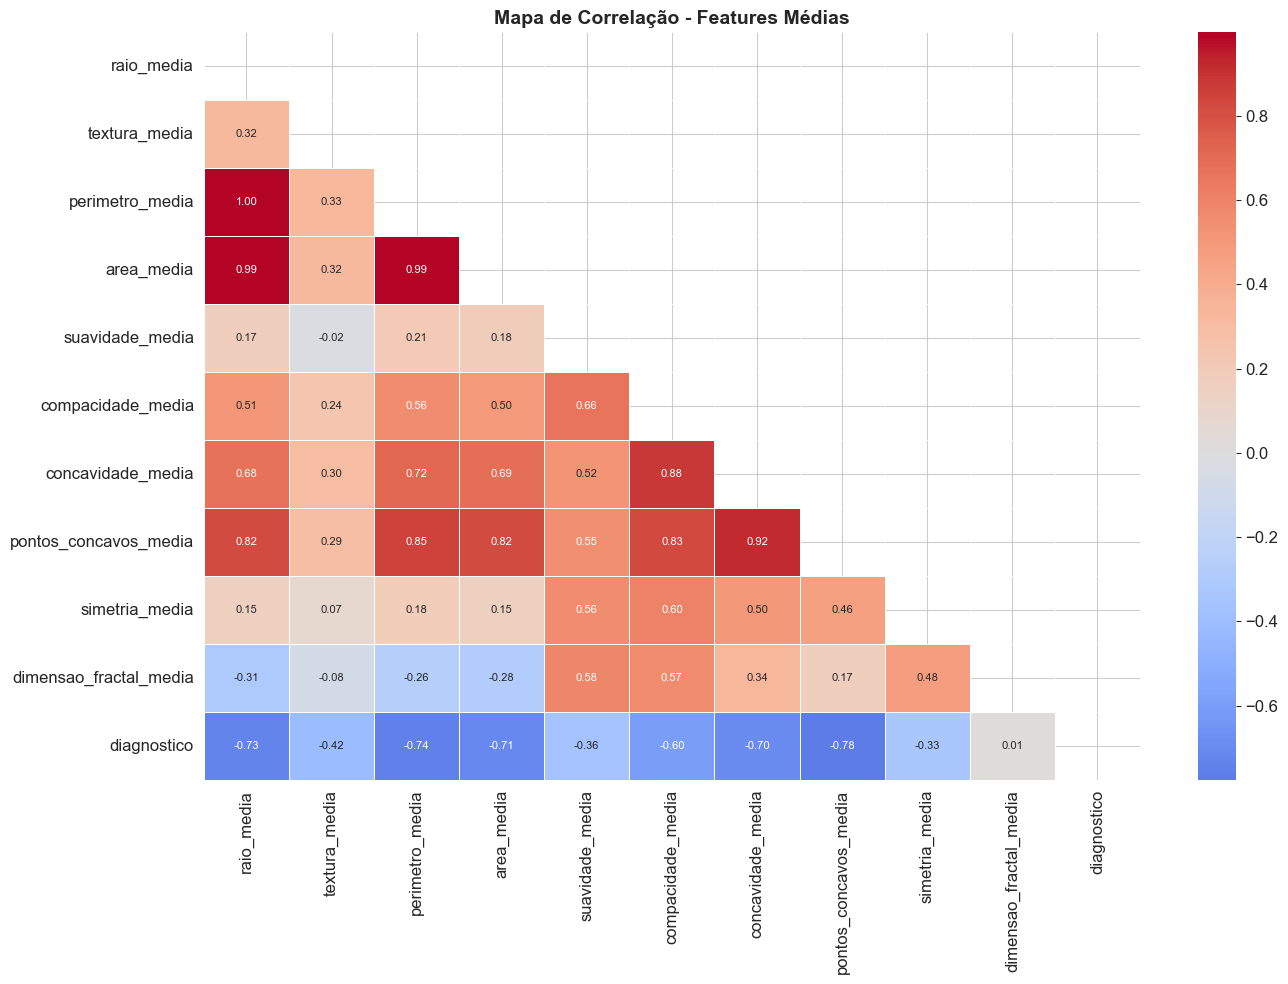

In [19]:
# Análise de correlação - vamos usar apenas as features 'mean' para o heatmap ficar legível
df_mean = df[features_mean + ['diagnostico']]
correlacao = plotar_correlacao(df_mean, titulo='Mapa de Correlação - Features Médias',
                        salvar_em=os.path.join(DIR_RESULTADOS, 'cm_correlacao.png'))

1. Mapa de correlação

O mapa de correlação foi apresentado utilizando apenas metade da matriz (triângulo inferior), o que é uma prática comum em análise exploratória de dados.

Isso ocorre porque a matriz de correlação é simétrica, ou seja, a correlação entre duas variáveis é igual independentemente da ordem (por exemplo, a correlação entre raio_medio e area_media é a mesma que entre area_media e raio_medio). 

Dessa forma, exibir a matriz completa resultaria em informação duplicada.

Ao mostrar apenas metade da matriz, evitamos redundância e reduzimos a poluição visual, tornando a interpretação mais clara e objetiva.

Além disso, a diagonal principal apresenta valor igual a 1, pois representa a correlação de cada variável com ela mesma.

2. Interpretação do mapa de correlação

Observa-se uma alta correlação entre variáveis geométricas, como raio_medio, perimetro_medio e area_media, já que todas estão diretamente relacionadas ao tamanho do tumor. Isso indica possível redundância entre essas variáveis.

Além disso, features como concavidade_media e pontos_concavos_media também apresentam forte correlação entre si, sugerindo que descrevem aspectos semelhantes da forma do tumor.

Em relação à variável alvo diagnostico, nota-se uma correlação negativa relevante com várias features, especialmente aquelas ligadas ao tamanho e irregularidade. Isso indica que valores mais altos nessas variáveis estão associados a tumores malignos.

Apesar dessas correlações, optamos inicialmente por manter todas as variáveis e avaliar o impacto nos modelos antes de aplicar técnicas de redução de dimensionalidade.

<!-- PARAMOS AQUI -->

In [ ]:
# Identificar pares de features com alta correlação (acima de 0.9)
# Isso nos ajuda a entender a redundância nos dados
correlacao_completa = df.drop('diagnostico', axis=1).corr()
pares_alta_corr = []

for i in range(len(correlacao_completa.columns)):
    for j in range(i + 1, len(correlacao_completa.columns)):
        if abs(correlacao_completa.iloc[i, j]) > 0.9:
            pares_alta_corr.append({
                'Feature 1': correlacao_completa.columns[i],
                'Feature 2': correlacao_completa.columns[j],
                'Correlação': correlacao_completa.iloc[i, j]
            })

df_corr = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f"Pares de features com correlação acima de 0.9: {len(df_corr)}")
df_corr

Pares de features com correlação acima de 0.9: 21


,Feature 1,Feature 2,Correlação
0,mean radius,mean perimeter,0.997855
18,worst radius,worst perimeter,0.993708
1,mean radius,mean area,0.987357
6,mean perimeter,mean area,0.986507
19,worst radius,worst area,0.984015
20,worst perimeter,worst area,0.977578
15,radius error,perimeter error,0.972794
8,mean perimeter,worst perimeter,0.970387
2,mean radius,worst radius,0.969539
7,mean perimeter,worst radius,0.969476


**Análise da correlação:** Existem vários pares de features altamente correlacionadas, como `mean radius`, `mean perimeter` e `mean area` — o que faz sentido, pois raio, perímetro e área de um círculo são matematicamente relacionados. Essa redundância não impede os modelos de funcionar, mas é algo a se considerar em trabalhos futuros (por exemplo, usando PCA para redução de dimensionalidade).

### 3.2 Separação dos Dados e Feature Scaling

Agora vamos separar as features (X) da variável alvo (y), dividir em treino e teste, e aplicar escalonamento.

**Por que escalonar os dados?** Algoritmos como KNN e Regressão Logística são sensíveis à escala das features. Se uma feature varia de 0 a 1 e outra de 0 a 1000, a segunda vai dominar o cálculo de distância. Vamos testar dois escaladores para ver qual funciona melhor:
- **StandardScaler**: transforma os dados para média 0 e desvio padrão 1
- **MinMaxScaler**: transforma os dados para o intervalo [0, 1]

In [ ]:
# Separar features (X) e variável alvo (y)
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Dividir em treino e teste (80/20)
# Usamos stratify=y para manter a proporção das classes em ambos os conjuntos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Conjunto de teste:  {X_teste.shape[0]} amostras")
print(f"\nProporção das classes no treino:")
print(f"  Maligno: {(y_treino == 0).sum()} ({(y_treino == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_treino == 1).sum()} ({(y_treino == 1).mean()*100:.1f}%)")
print(f"\nProporção das classes no teste:")
print(f"  Maligno: {(y_teste == 0).sum()} ({(y_teste == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_teste == 1).sum()} ({(y_teste == 1).mean()*100:.1f}%)")

Conjunto de treino: 455 amostras
Conjunto de teste:  114 amostras

Proporção das classes no treino:
  Maligno: 170 (37.4%)
  Benigno: 285 (62.6%)

Proporção das classes no teste:
  Maligno: 42 (36.8%)
  Benigno: 72 (63.2%)


### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual escalador usar, vamos testar ambos com um modelo simples (Regressão Logística) para ver qual produz melhores resultados. Essa é uma boa prática: ao invés de escolher arbitrariamente, deixamos os dados nos mostrarem qual funciona melhor.

In [ ]:
# Comparar StandardScaler vs MinMaxScaler usando validação cruzada
# Usamos Pipeline para garantir que o escalonamento é feito corretamente
# (ajustado no treino, aplicado no teste — evita data leakage)

# Pipeline com StandardScaler
pipeline_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Pipeline com MinMaxScaler
pipeline_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Validação cruzada com 5 folds
scores_standard = cross_val_score(pipeline_standard, X_treino, y_treino, cv=5, scoring='f1_weighted')
scores_minmax = cross_val_score(pipeline_minmax, X_treino, y_treino, cv=5, scoring='f1_weighted')

print("Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)")
print("=" * 65)
print(f"StandardScaler: {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")
print(f"MinMaxScaler:   {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

if scores_standard.mean() > scores_minmax.mean():
    print(f"\n→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = StandardScaler()
    nome_scaler = "StandardScaler"
else:
    print(f"\n→ MinMaxScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = MinMaxScaler()
    nome_scaler = "MinMaxScaler"

Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)
StandardScaler: 0.9801 (+/- 0.0129)
MinMaxScaler:   0.9711 (+/- 0.0194)

→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.


In [ ]:
# Aplicar o escalador escolhido nos dados
scaler = scaler_escolhido
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)  # Apenas transform, sem fit!

print(f"Escalador utilizado: {nome_scaler}")
print(f"Shape dos dados de treino escalonados: {X_treino_scaled.shape}")
print(f"Shape dos dados de teste escalonados: {X_teste_scaled.shape}")

Escalador utilizado: StandardScaler
Shape dos dados de treino escalonados: (455, 30)
Shape dos dados de teste escalonados: (114, 30)


---

## 4. Modelagem

Agora vamos treinar três modelos de classificação diferentes. A ideia é comparar abordagens distintas para entender qual se adapta melhor ao nosso problema:

1. **Regressão Logística** — modelo linear simples e interpretável, bom como baseline. Apesar do nome "regressão", é usado para classificação. Funciona bem quando as classes são linearmente separáveis.

2. **KNN (K-Nearest Neighbors)** — classifica com base na "vizinhança" de cada amostra. A ideia é simples: se os vizinhos mais próximos de um ponto são malignos, ele provavelmente é maligno. É sensível à escala dos dados (por isso o escalonamento é importante).

3. **Árvore de Decisão** — cria regras de decisão do tipo "se feature X > valor, então...". É muito interpretável e nos permite entender quais features o modelo considera mais importantes.

### 4.1 Modelo 1: Regressão Logística

REGRESSÃO LOGÍSTICA - Classification Report
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  → Gráfico salvo em: ..\resultados\cm_mc_regressao_logistica.png


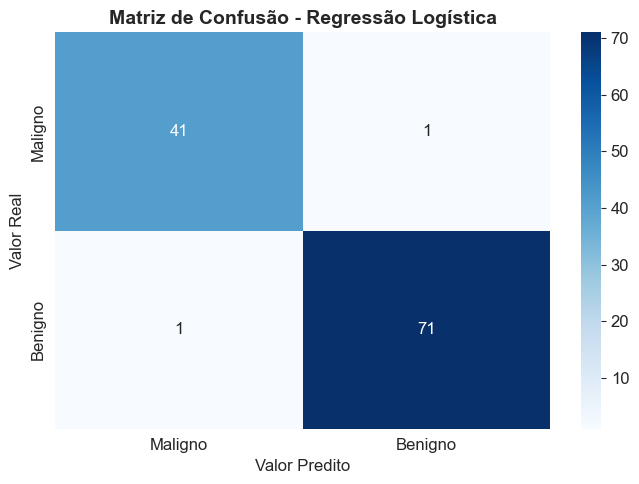

In [ ]:
# Modelo 1: Regressão Logística
# Escolhemos este modelo como baseline por ser simples e rápido
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_treino_scaled, y_treino)

# Predições
y_pred_lr = modelo_lr.predict(X_teste_scaled)
y_prob_lr = modelo_lr.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("REGRESSÃO LOGÍSTICA - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_lr, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_lr, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Regressão Logística',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_regressao_logistica.png'))

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

Para o KNN, precisamos definir o número de vizinhos (K). Vamos testar diferentes valores para encontrar o melhor.

  → Gráfico salvo em: ..\resultados\cm_melhor_k.png


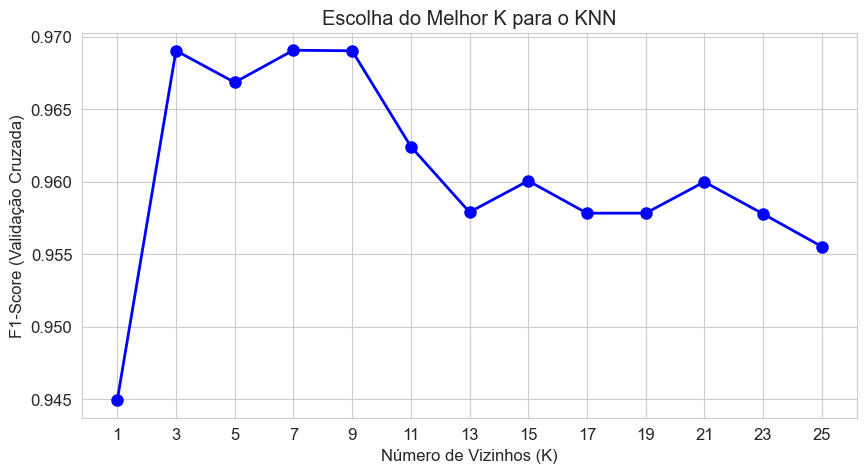

Melhor valor de K: 7 (F1-Score: 0.9691)


In [ ]:
# Encontrar o melhor valor de K usando validação cruzada
# Testamos valores ímpares de 1 a 25 para evitar empates na votação
valores_k = range(1, 26, 2)
scores_k = []

for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_treino_scaled, y_treino, cv=5, scoring='f1_weighted')
    scores_k.append(scores.mean())

# Plotar resultado
plt.figure(figsize=(10, 5))
plt.plot(list(valores_k), scores_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha do Melhor K para o KNN')
plt.xticks(list(valores_k))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png')}")
plt.show()

melhor_k = list(valores_k)[np.argmax(scores_k)]
print(f"Melhor valor de K: {melhor_k} (F1-Score: {max(scores_k):.4f})")

KNN (K=7) - Classification Report
              precision    recall  f1-score   support

     Maligno       1.00      0.93      0.96        42
     Benigno       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  → Gráfico salvo em: ..\resultados\cm_mc_knn.png


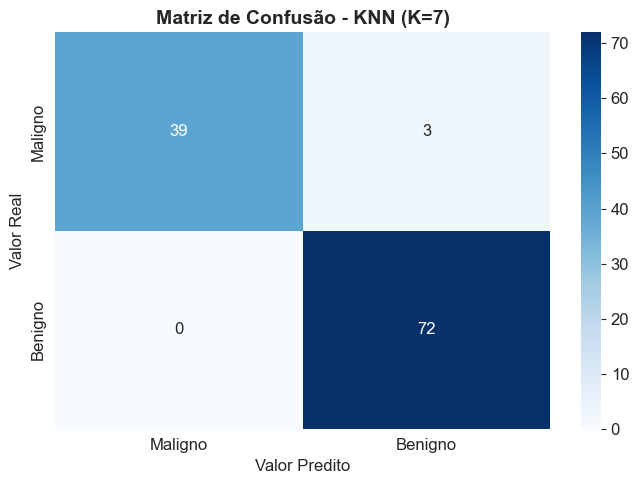

In [ ]:
# Modelo 2: KNN com o melhor K encontrado
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_treino_scaled, y_treino)

# Predições
y_pred_knn = modelo_knn.predict(X_teste_scaled)
y_prob_knn = modelo_knn.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print(f"KNN (K={melhor_k}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_knn, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_knn, ['Maligno', 'Benigno'],
                       titulo=f'Matriz de Confusão - KNN (K={melhor_k})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_knn.png'))

### 4.3 Modelo 3: Árvore de Decisão

A Árvore de Decisão é um modelo que cria regras de decisão hierárquicas. Uma vantagem é que não precisa de escalonamento dos dados, mas vamos usar os dados escalonados para manter a consistência na comparação.

ÁRVORE DE DECISÃO - Classification Report
              precision    recall  f1-score   support

     Maligno       0.87      0.93      0.90        42
     Benigno       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

  → Gráfico salvo em: ..\resultados\cm_mc_arvore_decisao.png


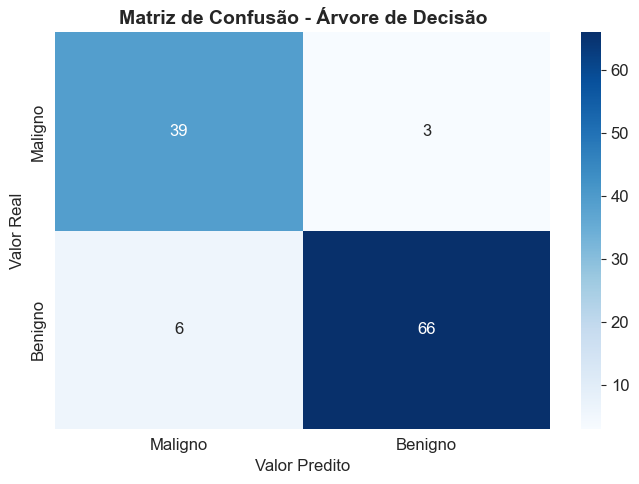

In [ ]:
# Modelo 3: Árvore de Decisão
# Limitamos a profundidade para evitar overfitting
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino_scaled, y_treino)

# Predições
y_pred_arvore = modelo_arvore.predict(X_teste_scaled)
y_prob_arvore = modelo_arvore.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("ÁRVORE DE DECISÃO - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_arvore, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_arvore, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Árvore de Decisão',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_arvore_decisao.png'))

---

## 5. Avaliação Comparativa dos Modelos

Agora vamos comparar os três modelos lado a lado para entender qual teve o melhor desempenho. 

### 5.1 Tabela Comparativa de Métricas

**Sobre a escolha da métrica principal:** Em um problema de diagnóstico de câncer, o **recall** (sensibilidade) é a métrica mais importante. Um falso negativo (classificar um tumor maligno como benigno) é muito mais perigoso do que um falso positivo (classificar um benigno como maligno). No primeiro caso, o paciente pode não receber o tratamento necessário; no segundo, exames adicionais serão realizados para confirmar.

In [ ]:
# Calcular métricas para cada modelo
metricas_lr = avaliar_modelo(y_teste, y_pred_lr, 'Regressão Logística')
metricas_knn = avaliar_modelo(y_teste, y_pred_knn, f'KNN (K={melhor_k})')
metricas_arvore = avaliar_modelo(y_teste, y_pred_arvore, 'Árvore de Decisão')

# Tabela comparativa
lista_metricas = [metricas_lr, metricas_knn, metricas_arvore]
df_comparacao, df_formatado = comparar_modelos(lista_metricas)

print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(df_comparacao.to_string())
print()

# Identificar o melhor modelo pelo recall (métrica mais importante neste caso)
melhor_recall = df_comparacao['Recall'].idxmax()
print(f"→ Melhor modelo considerando Recall: {melhor_recall}")
print(f"  Recall = {df_comparacao.loc[melhor_recall, 'Recall']:.4f}")

# Exibir tabela formatada
df_formatado

COMPARAÇÃO DOS MODELOS
                     Acurácia  Precisão    Recall  F1-Score
Modelo                                                     
Regressão Logística  0.982456  0.982456  0.982456  0.982456
KNN (K=7)            0.973684  0.974737  0.973684  0.973465
Árvore de Decisão    0.921053  0.923417  0.921053  0.921574

→ Melhor modelo considerando Recall: Regressão Logística
  Recall = 0.9825


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Regressão Logística,0.9825,0.9825,0.9825,0.9825
KNN (K=7),0.9737,0.9747,0.9737,0.9735
Árvore de Decisão,0.9211,0.9234,0.9211,0.9216


### 5.2 Validação Cruzada

Para ter uma avaliação mais robusta, vamos usar validação cruzada (5-fold) em cada modelo. Isso reduz o risco de termos resultados que dependem de uma divisão específica dos dados.

VALIDAÇÃO CRUZADA (5-Fold)
Regressão Logística      : Recall = 0.9807 (+/- 0.0065)
KNN (K=7)                : Recall = 0.9701 (+/- 0.0089)
Árvore de Decisão        : Recall = 0.9191 (+/- 0.0180)
  → Gráfico salvo em: ..\resultados\cm_validacao_cruzada.png


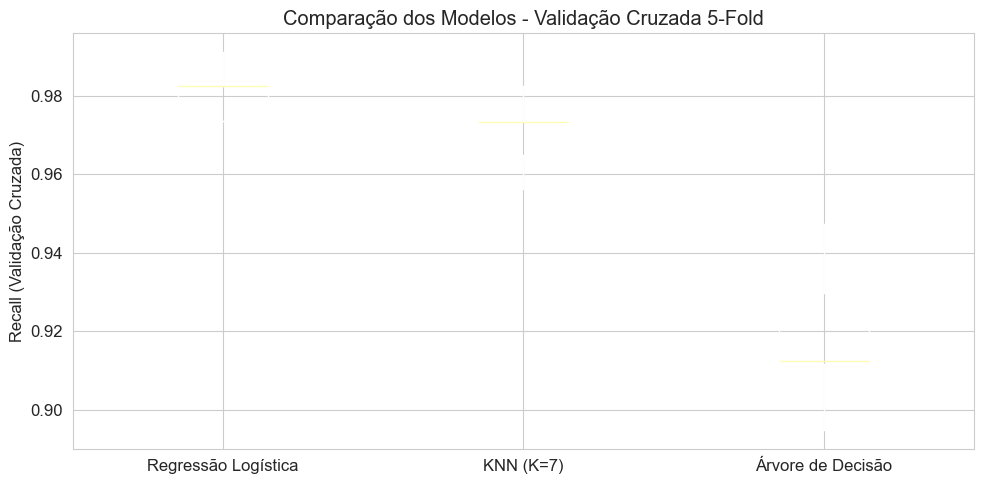

In [ ]:
# Validação cruzada com 5 folds para cada modelo
# Usamos Pipeline para integrar o escalonamento na validação cruzada

modelos_cv = {
    'Regressão Logística': LogisticRegression(max_iter=10000, random_state=42),
    f'KNN (K={melhor_k})': KNeighborsClassifier(n_neighbors=melhor_k),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("VALIDAÇÃO CRUZADA (5-Fold)")
print("=" * 60)

resultados_cv = {}
for nome, modelo in modelos_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='recall_weighted')
    resultados_cv[nome] = scores
    print(f"{nome:25s}: Recall = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Visualizar em boxplot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_ylabel('Recall (Validação Cruzada)')
ax.set_title('Comparação dos Modelos - Validação Cruzada 5-Fold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png')}")
plt.show()

### 5.3 Curvas ROC

A curva ROC (Receiver Operating Characteristic) nos permite visualizar o trade-off entre a taxa de verdadeiros positivos e a taxa de falsos positivos. Quanto mais próxima a curva do canto superior esquerdo, melhor o modelo. A área sob a curva (AUC) resume esse desempenho em um único número.

  → Gráfico salvo em: ..\resultados\cm_curvas_roc.png


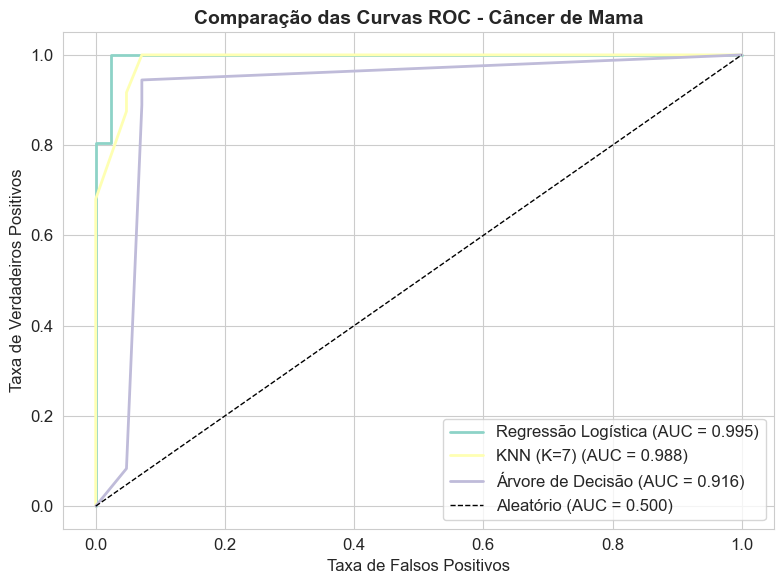

In [ ]:
# Plotar curvas ROC comparativas
resultados_roc = {
    'Regressão Logística': y_prob_lr,
    f'KNN (K={melhor_k})': y_prob_knn,
    'Árvore de Decisão': y_prob_arvore
}

plotar_curvas_roc_comparativas(
    y_teste, resultados_roc,
    titulo='Comparação das Curvas ROC - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_curvas_roc.png')
)

---

## 6. Interpretação dos Resultados

Além de saber que um modelo funciona bem, é importante entender **por que** ele faz determinadas predições. Isso é especialmente crítico na área médica, onde o modelo precisa ser explicável para que os médicos confiem nas suas sugestões.

### 6.1 Feature Importance (Árvore de Decisão)

A Árvore de Decisão nos dá uma medida direta de importância de cada feature: quanto cada uma contribui para a separação das classes.

  → Gráfico salvo em: ..\resultados\cm_feature_importance.png


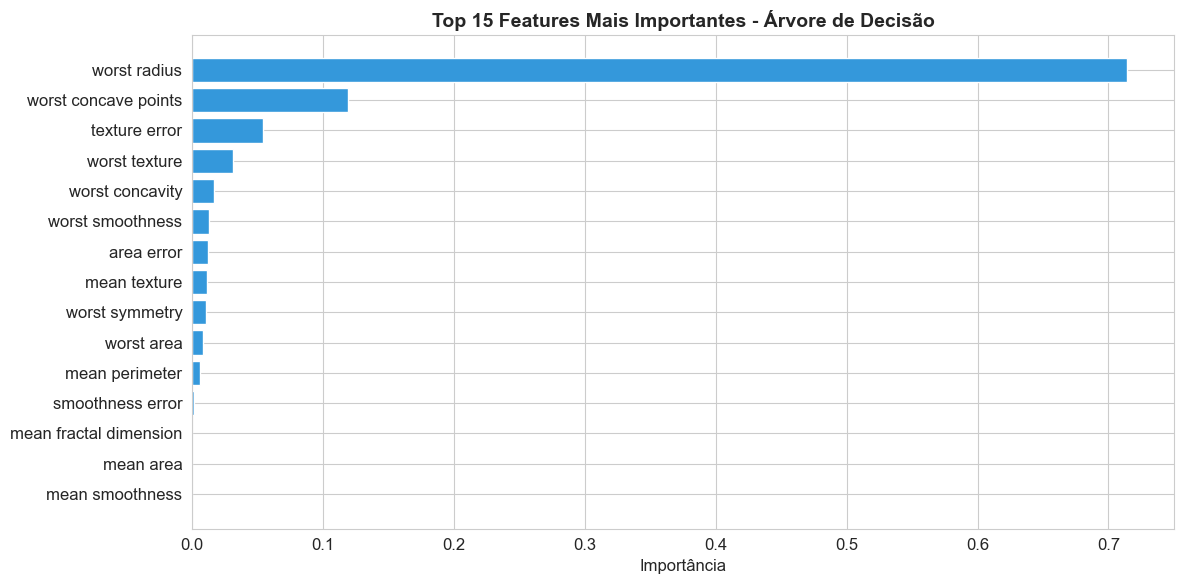

Top 10 Features mais importantes:
  1. worst radius                   - Importância: 0.7143
  2. worst concave points           - Importância: 0.1188
  3. texture error                  - Importância: 0.0539
  4. worst texture                  - Importância: 0.0315
  5. worst concavity                - Importância: 0.0167
  6. worst smoothness               - Importância: 0.0130
  7. area error                     - Importância: 0.0124
  8. mean texture                   - Importância: 0.0115
  9. worst symmetry                 - Importância: 0.0110
  10. worst area                     - Importância: 0.0087


In [ ]:
# Feature Importance da Árvore de Decisão
importancias = modelo_arvore.feature_importances_
indices = np.argsort(importancias)[::-1]

# Plotar as 15 features mais importantes
top_n = 15
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importancias[indices[:top_n]][::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features Mais Importantes - Árvore de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png')}")
plt.show()

# Exibir valores
print("Top 10 Features mais importantes:")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} - Importância: {importancias[indices[i]]:.4f}")

### 6.2 SHAP Values

SHAP (SHapley Additive exPlanations) é uma técnica que nos permite entender a contribuição de cada feature para cada predição individual. Diferente da feature importance que dá uma visão global, o SHAP mostra como cada feature influencia a predição para cada amostra.

Vamos aplicar o SHAP no modelo de Árvore de Decisão para entender suas decisões.

SHAP Summary Plot - Árvore de Decisão
Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.
Posição à direita = contribui para classificar como benigno.

  → Gráfico salvo em: ..\resultados\cm_shap_summary.png


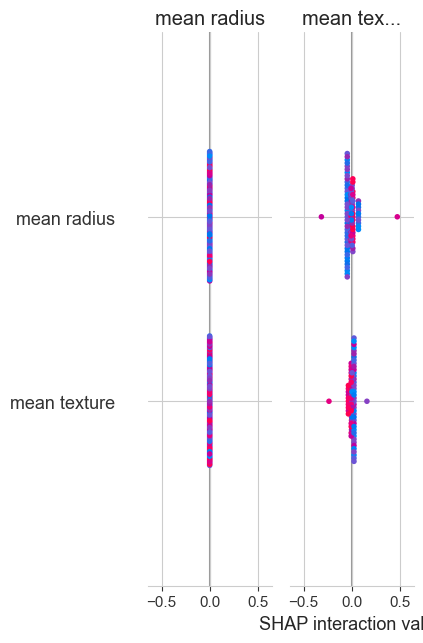

In [ ]:
# SHAP - Interpretabilidade do modelo de Árvore de Decisão
# Usamos TreeExplainer pois é otimizado para modelos baseados em árvores

explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_teste_scaled)

# Summary plot - mostra a importância e o efeito de cada feature
print("SHAP Summary Plot - Árvore de Decisão")
print("Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.")
print("Posição à direita = contribui para classificar como benigno.")
print()

# Converter para numpy array (necessário para indexação do SHAP)
feature_names_array = np.array(feature_names)

# Para classificação binária, pegamos os shap_values da classe 1 (benigno)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png')}")
plt.show()

  → Gráfico salvo em: ..\resultados\cm_shap_bar.png


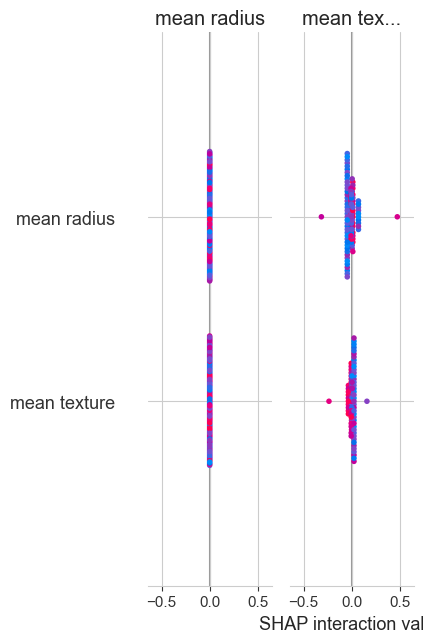

In [ ]:
# SHAP Bar Plot - visão resumida da importância média de cada feature
shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    plot_type='bar',
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png')}")
plt.show()

**Interpretação do SHAP:** Os gráficos SHAP confirmam que features como `worst perimeter`, `worst concave points` e `mean concave points` são as mais influentes na classificação. Isso é consistente com o conhecimento médico: tumores malignos tendem a ter bordas irregulares (alto perímetro) e mais pontos côncavos (indicando forma irregular da célula).

---

## 7. Discussão Crítica

### O modelo pode ser utilizado na prática?

Os modelos apresentaram bons resultados nas métricas de avaliação, especialmente a Regressão Logística e o KNN. No entanto, é fundamental considerar os seguintes pontos:

**Pontos fortes:**
- Altas taxas de recall, o que é crucial em diagnósticos médicos (minimizar falsos negativos)
- O modelo é capaz de destacar quais características são mais relevantes para o diagnóstico
- O processamento é rápido e pode auxiliar na triagem de exames

**Limitações:**
- O dataset é relativamente pequeno (569 amostras). Em um cenário real, seria necessário treinar com muito mais dados
- Os dados são limpos e bem estruturados, o que raramente acontece em dados reais de hospitais
- O modelo trabalha apenas com features numéricas extraídas — não analisa as imagens diretamente

**O papel do médico:**
É essencial ressaltar que **o médico sempre deve ter a palavra final no diagnóstico**. O modelo de ML deve ser visto como uma **ferramenta de apoio**, não como um substituto do profissional. Ele pode:
- Auxiliar na triagem rápida de exames
- Chamar a atenção para casos que merecem análise mais cuidadosa
- Servir como "segunda opinião" automatizada

Mas a decisão final, considerando o histórico do paciente, exame clínico e outros fatores, sempre será do médico.

---

*Notebook desenvolvido como parte do Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs*